# Fork B.2 — Windowed 7-mer Graph + GNN (PyTorch only)

Pure PyTorch implementation (no PyG).

In [14]:
import os
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score
)

def resolve_device(prefer: Optional[str] = None) -> torch.device:
    # prefer: None or 'cpu'/'mps'/'cuda'
    if prefer is not None:
        return torch.device(prefer)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print("Torch:", torch.__version__)
print("Device:", DEVICE)


Torch: 2.9.0
Device: mps


In [31]:
def read_fasta(path: Path) -> Tuple[List[str], List[str]]:
    headers, seqs = [], []
    cur = []
    head = None
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if head is not None:
                    seqs.append("".join(cur).upper())
                    cur = []
                head = line[1:].strip()
                headers.append(head)
            else:
                cur.append(line)
        if head is not None:
            seqs.append("".join(cur).upper())
    assert len(headers) == len(seqs)
    return headers, seqs

def load_feature_labels(path: Path) -> Dict[str, str]:
    """Load multiclass labels from features-tpase style file.
    Format: >header<tab>label (e.g., >hAT_1-aAnoBae#DNA/hAT\tDNA/hAT)
    Returns dict mapping header -> label string.
    """
    label_dict = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 2:
                continue
            header = parts[0][1:] if parts[0].startswith(">") else parts[0]
            label_dict[header] = parts[1]
    return label_dict

def load_binary_feature_labels(path: Path) -> Dict[str, int]:
    """Load binary labels (1 if not None, 0 if None)."""
    label_dict = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 2:
                continue
            header = parts[0][1:] if parts[0].startswith(">") else parts[0]
            label_dict[header] = 0 if parts[1] == "None" else 1
    return label_dict

def header_to_tag(header: str) -> str:
    """Extract TE class from header like 'hAT_1-aAnoBae#DNA/hAT' -> 'DNA/hAT'."""
    if "#" in header:
        return header.split("#")[1]  # Part after #
    return header

def build_multiclass_labels_from_headers(headers: List[str]):
    tags = [header_to_tag(h) for h in headers]
    uniq = sorted(set(tags))
    tag_to_id = {t:i for i,t in enumerate(uniq)}
    y = np.array([tag_to_id[t] for t in tags], dtype=np.int64)
    return y, tag_to_id, uniq

def make_binary_labels_from_tags(headers: List[str], negative_tag: str = "None") -> np.ndarray:
    tags = [header_to_tag(h) for h in headers]
    return np.array([0 if t == negative_tag else 1 for t in tags], dtype=np.int64)

In [16]:
# ASCII -> {0,1,2,3,4} for A,C,G,T,other
_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch,val in [("A",0),("C",1),("G",2),("T",3),("a",0),("c",1),("g",2),("t",3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3,2,1,0], dtype=np.uint8)  # A<->T, C<->G in 0..3

def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code

def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code

def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2

def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)

@dataclass
class KmerWindowFeaturizer:
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str):
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii","ignore"), dtype=np.uint8)]
        L = int(arr.size)
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i+k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


In [17]:
@dataclass
class GraphSample:
    x: torch.Tensor
    edge_index: torch.Tensor
    y: torch.Tensor
    header: str

def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    edges = []
    if n > 1:
        src = np.arange(n-1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2,0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s,d], axis=0)
    return torch.from_numpy(ei)

class WindowGraphDataset(torch.utils.data.Dataset):
    def __init__(self, headers: List[str], sequences: List[str], y: np.ndarray, featurizer: KmerWindowFeaturizer):
        self.headers=headers
        self.seqs=sequences
        self.y=y.astype(np.int64)
        self.feat=featurizer

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx: int) -> GraphSample:
        h=self.headers[idx]
        seq=self.seqs[idx]
        X,_=self.feat.featurize_sequence(seq)
        x=torch.from_numpy(X).to(torch.float32)
        ei=build_chain_edge_index(x.size(0), undirected=True, self_loops=True)
        y=torch.tensor(int(self.y[idx]), dtype=torch.int64)
        return GraphSample(x=x, edge_index=ei, y=y, header=h)

def collate_graphs(batch: List[GraphSample]):
    xs=[]; eis=[]; ys=[]; headers=[]
    batch_vecs=[]
    node_offset=0
    for gi,s in enumerate(batch):
        n=s.x.size(0)
        xs.append(s.x)
        eis.append(s.edge_index + node_offset)
        ys.append(s.y)
        headers.append(s.header)
        batch_vecs.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n
    x=torch.cat(xs, dim=0)
    edge_index=torch.cat(eis, dim=1) if eis else torch.zeros((2,0),dtype=torch.int64)
    batch_vec=torch.cat(batch_vecs, dim=0)
    y=torch.stack(ys, dim=0)
    return x, edge_index, batch_vec, y, headers

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    out=torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt=torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out/cnt


In [18]:
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)

class GNNClassifier(nn.Module):
    def __init__(self, in_dim: int, hidden: int, num_classes: int, n_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        layers=[]
        d=in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d=hidden
        self.layers=nn.ModuleList(layers)
        self.head=nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, edge_index)
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        g = scatter_mean(x, batch_vec, dim_size=B)
        return self.head(g)


In [35]:
import time
from sklearn.metrics import classification_report, confusion_matrix

def compute_class_weights(y: np.ndarray, num_classes: int) -> torch.Tensor:
    counts = np.bincount(y, minlength=num_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    w = counts.sum() / counts
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, 
                                   reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

def augment_reverse_complement(seq: str) -> str:
    """Return reverse complement of DNA sequence."""
    comp = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}
    return ''.join(comp.get(c, 'N') for c in reversed(seq.upper()))

# ============================================================================
# PRE-COMPUTED FEATURE DATASET (much faster training)
# ============================================================================
class PrecomputedGraphDataset(torch.utils.data.Dataset):
    """Dataset with pre-computed features for faster training."""
    def __init__(self, features: List[np.ndarray], labels: np.ndarray, headers: List[str]):
        self.features = features  # List of (n_windows, dim) arrays
        self.labels = labels.astype(np.int64)
        self.headers = headers
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx: int) -> GraphSample:
        X = self.features[idx]
        x = torch.from_numpy(X).to(torch.float32)
        ei = build_chain_edge_index(x.size(0), undirected=True, self_loops=True)
        y = torch.tensor(int(self.labels[idx]), dtype=torch.int64)
        return GraphSample(x=x, edge_index=ei, y=y, header=self.headers[idx])

def precompute_features(sequences: List[str], featurizer: KmerWindowFeaturizer, 
                        desc: str = "Featurizing") -> List[np.ndarray]:
    """Pre-compute k-mer features for all sequences."""
    from tqdm import tqdm
    features = []
    for seq in tqdm(sequences, desc=desc, leave=False):
        X, _ = featurizer.featurize_sequence(seq)
        features.append(X)
    return features

# ============================================================================
# EVALUATION UTILITIES
# ============================================================================
@torch.no_grad()
def predict_loader(model: nn.Module, loader, device: torch.device):
    model.eval()
    logits_list, y_list, headers = [], [], []
    for x, edge_index, batch_vec, y, h in loader:
        x, edge_index, batch_vec = x.to(device), edge_index.to(device), batch_vec.to(device)
        logits = model(x, edge_index, batch_vec)
        logits_list.append(logits.detach().cpu())
        y_list.append(y.detach().cpu())
        headers.extend(h)
    logits = torch.cat(logits_list, dim=0) if logits_list else torch.empty((0, 1))
    y = torch.cat(y_list, dim=0) if y_list else torch.empty((0,), dtype=torch.int64)
    return logits, y, headers

def evaluate_multiclass(logits: torch.Tensor, y: torch.Tensor) -> Dict[str, float]:
    y_np = y.numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    out = {}
    out['acc'] = accuracy_score(y_np, pred) if len(y_np) else float('nan')
    out['balanced_acc'] = balanced_accuracy_score(y_np, pred) if len(y_np) else float('nan')
    try:
        out['auroc_macro_ovr'] = float(roc_auc_score(y_np, probs, multi_class='ovr', average='macro'))
    except:
        out['auroc_macro_ovr'] = float('nan')
    try:
        Y = np.zeros_like(probs)
        Y[np.arange(len(y_np)), y_np] = 1.0
        out['auprc_macro'] = float(average_precision_score(Y, probs, average='macro'))
    except:
        out['auprc_macro'] = float('nan')
    return out

def evaluate_per_class(logits: torch.Tensor, y: torch.Tensor, id_to_tag: List[str]) -> Dict:
    """Get per-class precision, recall, F1."""
    y_np = y.numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    
    report = classification_report(y_np, pred, target_names=id_to_tag, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_np, pred)
    
    return {"report": report, "confusion_matrix": cm, "predictions": pred, "true": y_np}

def print_per_class_metrics(eval_result: Dict, id_to_tag: List[str], top_n: int = 15):
    """Print per-class metrics sorted by F1 score."""
    report = eval_result["report"]
    rows = []
    for tag in id_to_tag:
        if tag in report:
            r = report[tag]
            rows.append((tag, r['precision'], r['recall'], r['f1-score'], int(r['support'])))
    
    rows.sort(key=lambda x: -x[3])  # Sort by F1
    print(f"\n{'Class':<25} {'Prec':>6} {'Recall':>6} {'F1':>6} {'Support':>8}")
    print("-" * 55)
    for tag, p, r, f1, sup in rows[:top_n]:
        print(f"{tag:<25} {p:>6.3f} {r:>6.3f} {f1:>6.3f} {sup:>8}")
    if len(rows) > top_n:
        print(f"... and {len(rows) - top_n} more classes")

# ============================================================================
# MAIN TRAINING FUNCTION
# ============================================================================
def run_train_gnn_full(
    fasta_path: Path,
    label_source: str = "fasta",           # "fasta" or "file"
    label_path: Optional[Path] = None,     # Required if label_source="file"
    exclude_tags: Optional[List[str]] = None,
    k: int = 7,
    dim: int = 2048,
    window: int = 512,
    stride: int = 256,
    hidden: int = 128,
    n_layers: int = 3,
    dropout: float = 0.1,
    batch_size: int = 32,
    epochs: int = 20,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 5,
    random_state: int = 42,
    min_class_count: int = 50,
    device: Optional[torch.device] = None,
    num_workers: int = 0,
    # K-fold
    n_folds: int = 5,
    test_size: float = 0.2,
    # Imbalance handling
    use_focal_loss: bool = True,
    focal_gamma: float = 2.0,
    label_smoothing: float = 0.0,
    oversample_minority: bool = False,
    use_reverse_complement: bool = False,
    # Training improvements
    use_lr_scheduler: bool = True,
    gradient_clip: float = 1.0,
    use_mixed_precision: bool = False,    # For GPU
    # Output
    save_dir: Optional[Path] = None,
    precompute: bool = True,              # Pre-compute features (much faster)
):
    """
    Full training pipeline with K-fold CV.
    Supports both FASTA header labels and external label files.
    """
    from sklearn.model_selection import StratifiedKFold
    
    device = resolve_device(None if device is None else str(device))
    print(f"Device: {device}")
    print(f"Mixed precision: {use_mixed_precision}")
    
    start_time = time.time()
    
    # =========== LOAD DATA ===========
    headers, sequences = read_fasta(Path(fasta_path))
    print(f"Loaded {len(sequences)} sequences")
    
    # Get labels
    if label_source == "fasta":
        tags = [header_to_tag(h) for h in headers]
    elif label_source == "file":
        assert label_path is not None
        label_dict = load_feature_labels(Path(label_path))
        # Filter to matched only
        matched_h, matched_s, matched_t = [], [], []
        for h, s in zip(headers, sequences):
            if h in label_dict:
                matched_h.append(h)
                matched_s.append(s)
                matched_t.append(label_dict[h])
        headers, sequences, tags = matched_h, matched_s, matched_t
        print(f"Matched {len(headers)} sequences with label file")
    else:
        raise ValueError(f"Unknown label_source: {label_source}")
    
    # Exclude tags
    if exclude_tags:
        exclude_set = set(exclude_tags)
        keep = [(h, s, t) for h, s, t in zip(headers, sequences, tags) if t not in exclude_set]
        excluded = len(headers) - len(keep)
        headers, sequences, tags = zip(*keep) if keep else ([], [], [])
        headers, sequences, tags = list(headers), list(sequences), list(tags)
        print(f"Excluded {excluded} sequences with tags in {exclude_tags}")
    
    print(f"Remaining: {len(sequences)} sequences")
    
    # Build label mapping
    from collections import Counter
    tag_counts = Counter(tags)
    uniq = sorted(set(tags))
    tag_to_id = {t: i for i, t in enumerate(uniq)}
    id_to_tag = uniq
    y = np.array([tag_to_id[t] for t in tags], dtype=np.int64)
    
    # Print distribution
    print(f"\nClass distribution ({len(id_to_tag)} classes):")
    for tag, cnt in tag_counts.most_common(15):
        print(f"  {tag}: {cnt}")
    if len(tag_counts) > 15:
        print(f"  ... and {len(tag_counts) - 15} more")
    
    # Drop rare classes
    if min_class_count > 1:
        counts = np.bincount(y, minlength=len(id_to_tag))
        keep_cls = np.where(counts >= min_class_count)[0]
        drop_cls = np.where(counts < min_class_count)[0]
        
        if drop_cls.size:
            keep_mask = np.isin(y, keep_cls)
            dropped_n = int((~keep_mask).sum())
            print(f"\nDropping {dropped_n} sequences from {drop_cls.size} classes with <{min_class_count} samples")
            
            headers = [h for h, m in zip(headers, keep_mask) if m]
            sequences = [s for s, m in zip(sequences, keep_mask) if m]
            y = y[keep_mask]
            
            # Remap
            keep_cls = keep_cls.tolist()
            old_to_new = {old: new for new, old in enumerate(keep_cls)}
            y = np.array([old_to_new[i] for i in y], dtype=np.int64)
            id_to_tag = [id_to_tag[old] for old in keep_cls]
    
    num_classes = len(id_to_tag)
    print(f"\nFinal: {len(sequences)} sequences, {num_classes} classes")
    
    # =========== PRE-COMPUTE FEATURES ===========
    feat = KmerWindowFeaturizer(k=k, dim=dim, window=window, stride=stride, add_pos=True, l2_normalize=True)
    
    if precompute:
        print("\nPre-computing features (this speeds up training significantly)...")
        all_features = precompute_features(sequences, feat, desc="Featurizing")
        print(f"Features computed in {time.time() - start_time:.1f}s")
    
    # =========== TRAIN/TEST SPLIT ===========
    idx_all = np.arange(len(sequences))
    idx_trainval, idx_te = train_test_split(idx_all, test_size=test_size, random_state=random_state, stratify=y)
    
    print(f"\nSplit: {len(idx_trainval)} train+val, {len(idx_te)} test")
    
    # =========== K-FOLD CV ===========
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    fold_results = []
    in_dim = dim + 1
    
    scaler = torch.amp.GradScaler('cuda') if use_mixed_precision and device.type == 'cuda' else None
    
    for fold_i, (tr_rel, va_rel) in enumerate(skf.split(idx_trainval, y[idx_trainval])):
        print(f"\n{'='*50}")
        print(f"FOLD {fold_i + 1}/{n_folds}")
        print(f"{'='*50}")
        
        idx_tr = idx_trainval[tr_rel]
        idx_va = idx_trainval[va_rel]
        
        # Get fold data
        if precompute:
            feat_tr = [all_features[i] for i in idx_tr]
            feat_va = [all_features[i] for i in idx_va]
            ds_tr = PrecomputedGraphDataset(feat_tr, y[idx_tr], [headers[i] for i in idx_tr])
            ds_va = PrecomputedGraphDataset(feat_va, y[idx_va], [headers[i] for i in idx_va])
        else:
            ds_tr = WindowGraphDataset([headers[i] for i in idx_tr], [sequences[i] for i in idx_tr], y[idx_tr], feat)
            ds_va = WindowGraphDataset([headers[i] for i in idx_va], [sequences[i] for i in idx_va], y[idx_va], feat)
        
        # Optional: Oversample
        if oversample_minority and precompute:
            y_tr = y[idx_tr]
            counts = np.bincount(y_tr, minlength=num_classes)
            max_count = counts.max()
            new_feat, new_y, new_h = list(feat_tr), list(y_tr), [headers[i] for i in idx_tr]
            for cls in range(num_classes):
                cls_idx = np.where(y_tr == cls)[0]
                if len(cls_idx) > 0 and len(cls_idx) < max_count:
                    n_add = max_count - len(cls_idx)
                    add_idx = np.random.choice(cls_idx, size=n_add, replace=True)
                    for ai in add_idx:
                        new_feat.append(feat_tr[ai])
                        new_y.append(cls)
                        new_h.append(new_h[ai] + "_os")
            ds_tr = PrecomputedGraphDataset(new_feat, np.array(new_y), new_h)
        
        loader_tr = torch.utils.data.DataLoader(ds_tr, batch_size=batch_size, shuffle=True, 
                                                  num_workers=num_workers, collate_fn=collate_graphs)
        loader_va = torch.utils.data.DataLoader(ds_va, batch_size=batch_size, shuffle=False,
                                                  num_workers=num_workers, collate_fn=collate_graphs)
        
        # Model
        model = GNNClassifier(in_dim=in_dim, hidden=hidden, num_classes=num_classes, 
                              n_layers=n_layers, dropout=dropout).to(device)
        
        class_w = compute_class_weights(y[idx_tr], num_classes).to(device)
        if use_focal_loss:
            loss_fn = FocalLoss(alpha=class_w, gamma=focal_gamma, label_smoothing=label_smoothing)
        else:
            loss_fn = nn.CrossEntropyLoss(weight=class_w, label_smoothing=label_smoothing)
        
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        if use_lr_scheduler:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
        
        best_state, best_score, bad = None, -float("inf"), 0
        
        for ep in range(1, epochs + 1):
            model.train()
            running, n_graphs = 0.0, 0
            
            for x, edge_index, batch_vec, yb, _ in loader_tr:
                x, edge_index, batch_vec, yb = x.to(device), edge_index.to(device), batch_vec.to(device), yb.to(device)
                
                if use_mixed_precision and scaler:
                    with torch.amp.autocast('cuda'):
                        logits = model(x, edge_index, batch_vec)
                        loss = loss_fn(logits, yb)
                    opt.zero_grad(set_to_none=True)
                    scaler.scale(loss).backward()
                    if gradient_clip > 0:
                        scaler.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                    scaler.step(opt)
                    scaler.update()
                else:
                    logits = model(x, edge_index, batch_vec)
                    loss = loss_fn(logits, yb)
                    opt.zero_grad(set_to_none=True)
                    loss.backward()
                    if gradient_clip > 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                    opt.step()
                
                running += float(loss.item()) * yb.size(0)
                n_graphs += yb.size(0)
            
            if use_lr_scheduler:
                scheduler.step()
            
            train_loss = running / max(1, n_graphs)
            
            # Validate
            val_logits, val_y, _ = predict_loader(model, loader_va, device)
            m = evaluate_multiclass(val_logits, val_y)
            
            current_lr = opt.param_groups[0]['lr']
            print(f"  Ep {ep:02d} | loss={train_loss:.4f} | bacc={m['balanced_acc']:.4f} | auroc={m['auroc_macro_ovr']:.4f} | lr={current_lr:.2e}")
            
            score = m["balanced_acc"]
            if score > best_score + 1e-4:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    print(f"  Early stopping at epoch {ep}")
                    break
        
        if best_state:
            model.load_state_dict(best_state)
            model.to(device)
        
        val_logits, val_y, _ = predict_loader(model, loader_va, device)
        fold_metrics = evaluate_multiclass(val_logits, val_y)
        fold_results.append(fold_metrics)
        print(f"  Fold {fold_i+1}: bacc={fold_metrics['balanced_acc']:.4f}")
    
    # =========== CV SUMMARY ===========
    print(f"\n{'='*50}")
    print("CV SUMMARY")
    print(f"{'='*50}")
    cv_metrics = {}
    for key in fold_results[0].keys():
        values = [f[key] for f in fold_results]
        cv_metrics[key] = {"mean": np.mean(values), "std": np.std(values)}
        print(f"{key}: {cv_metrics[key]['mean']:.4f} ± {cv_metrics[key]['std']:.4f}")
    
    # =========== FINAL MODEL ===========
    print(f"\n{'='*50}")
    print("TRAINING FINAL MODEL")
    print(f"{'='*50}")
    
    if precompute:
        feat_trainval = [all_features[i] for i in idx_trainval]
        feat_te = [all_features[i] for i in idx_te]
        ds_trainval = PrecomputedGraphDataset(feat_trainval, y[idx_trainval], [headers[i] for i in idx_trainval])
        ds_te = PrecomputedGraphDataset(feat_te, y[idx_te], [headers[i] for i in idx_te])
    else:
        ds_trainval = WindowGraphDataset([headers[i] for i in idx_trainval], [sequences[i] for i in idx_trainval], y[idx_trainval], feat)
        ds_te = WindowGraphDataset([headers[i] for i in idx_te], [sequences[i] for i in idx_te], y[idx_te], feat)
    
    loader_trainval = torch.utils.data.DataLoader(ds_trainval, batch_size=batch_size, shuffle=True,
                                                    num_workers=num_workers, collate_fn=collate_graphs)
    loader_te = torch.utils.data.DataLoader(ds_te, batch_size=batch_size, shuffle=False,
                                              num_workers=num_workers, collate_fn=collate_graphs)
    
    model = GNNClassifier(in_dim=in_dim, hidden=hidden, num_classes=num_classes,
                          n_layers=n_layers, dropout=dropout).to(device)
    class_w = compute_class_weights(y[idx_trainval], num_classes).to(device)
    loss_fn = FocalLoss(alpha=class_w, gamma=focal_gamma) if use_focal_loss else nn.CrossEntropyLoss(weight=class_w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if use_lr_scheduler:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    
    for ep in range(1, epochs + 1):
        model.train()
        for x, edge_index, batch_vec, yb, _ in loader_trainval:
            x, edge_index, batch_vec, yb = x.to(device), edge_index.to(device), batch_vec.to(device), yb.to(device)
            logits = model(x, edge_index, batch_vec)
            loss = loss_fn(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            if gradient_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            opt.step()
        if use_lr_scheduler:
            scheduler.step()
        if ep % 2 == 0:
            print(f"  Epoch {ep}/{epochs}")
    
    # =========== TEST EVALUATION ===========
    test_logits, test_y, test_headers = predict_loader(model, loader_te, device)
    test_metrics = evaluate_multiclass(test_logits, test_y)
    test_per_class = evaluate_per_class(test_logits, test_y, id_to_tag)
    
    print(f"\n{'='*50}")
    print("TEST RESULTS")
    print(f"{'='*50}")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")
    
    print_per_class_metrics(test_per_class, id_to_tag)
    
    total_time = time.time() - start_time
    print(f"\nTotal time: {total_time/60:.1f} minutes")
    
    # Save checkpoint
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        ckpt_path = save_dir / "gnn_best.pt"
        torch.save({
            "model_state": model.state_dict(),
            "featurizer": feat.__dict__,
            "id_to_tag": id_to_tag,
            "cv_metrics": cv_metrics,
            "test_metrics": test_metrics,
        }, ckpt_path)
        print(f"Saved checkpoint to {ckpt_path}")
    
    return {
        "model": model,
        "featurizer": feat,
        "cv_metrics": cv_metrics,
        "fold_results": fold_results,
        "test": {"logits": test_logits, "y": test_y, "headers": test_headers, 
                 "metrics": test_metrics, "per_class": test_per_class},
        "id_to_tag": id_to_tag,
        "device": str(device),
        "total_time_sec": total_time,
    }

In [20]:
@torch.no_grad()
def predict_sequence(model: nn.Module, featurizer: KmerWindowFeaturizer, seq: str, device: torch.device):
    X,_ = featurizer.featurize_sequence(seq)
    x = torch.from_numpy(X).to(device)
    edge_index = build_chain_edge_index(x.size(0), undirected=True, self_loops=True).to(device)
    batch_vec = torch.zeros((x.size(0),), dtype=torch.int64, device=device)
    logits = model(x, edge_index, batch_vec).squeeze(0)
    return torch.softmax(logits, dim=0).detach().cpu().numpy()

def topk_classes(probs: np.ndarray, id_to_tag=None, k: int = 5):
    idx = np.argsort(-probs)[:k]
    return [((id_to_tag[i] if id_to_tag else int(i)), float(probs[i])) for i in idx]

def find_misclassified(logits: torch.Tensor, y: torch.Tensor, headers: List[str], id_to_tag=None, max_rows: int = 50):
    probs = torch.softmax(logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    y_np = y.numpy()
    bad = np.where(pred != y_np)[0]
    rows=[]
    for i in bad[:max_rows]:
        rows.append({"header":headers[i], "true": (id_to_tag[y_np[i]] if id_to_tag else int(y_np[i])), "pred": (id_to_tag[pred[i]] if id_to_tag else int(pred[i])), "p_pred": float(probs[i, pred[i]])})
    return rows, int(bad.size)

def save_checkpoint(path: Path, model: nn.Module, featurizer: KmerWindowFeaturizer, id_to_tag=None):
    ckpt={"model_state": model.state_dict(), "featurizer": featurizer.__dict__, "id_to_tag": id_to_tag}
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(ckpt, path)
    print("Saved:", path)

def load_checkpoint(path: Path, hidden: int, n_layers: int, dropout: float = 0.1, device: Optional[torch.device] = None):
    device = resolve_device(None if device is None else str(device))
    ckpt=torch.load(path, map_location="cpu")
    feat=KmerWindowFeaturizer(**ckpt["featurizer"])
    id_to_tag=ckpt.get("id_to_tag", None)
    state=ckpt["model_state"]
    num_classes = state["head.3.weight"].shape[0]
    in_dim = feat.dim + (1 if feat.add_pos else 0)
    model = GNNClassifier(in_dim=in_dim, hidden=hidden, num_classes=num_classes, n_layers=n_layers, dropout=dropout)
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    return model, feat, id_to_tag, device


## Example usage (edit paths)

```python
FASTA_PATH = Path("../data/vgp/all_vgp_tes.fa")

results = run_train_gnn(
    fasta_path=FASTA_PATH,
    label_mode="multiclass",
    subset_size=20000,
    batch_size=16,
    epochs=25,
    patience=5,
    dim=2048,
    window=512,
    stride=256,
)
```


In [36]:
# ============================================================================
# RUN EXPERIMENT - Full FASTA dataset (all TE classes)
# ============================================================================
# Use FASTA header labels (48 classes → ~33 after filtering)
# Excludes "Unknown" class, keeps classes with 50+ samples

results = run_train_gnn_full(
    fasta_path=Path("../data/vgp/all_vgp_tes.fa"),
    label_source="fasta",                 # Use FASTA header labels
    exclude_tags=["Unknown"],             # Exclude Unknown class
    # Features
    k=7, dim=2048, window=512, stride=256,
    # Model
    hidden=128, n_layers=3, dropout=0.2,
    # Training
    batch_size=32, epochs=5, lr=1e-3, weight_decay=1e-4, patience=3,
    min_class_count=50,
    # K-fold
    n_folds=5, test_size=0.2,
    # Imbalance handling
    use_focal_loss=True, focal_gamma=2.0, label_smoothing=0.0,
    oversample_minority=False,
    # Training improvements
    use_lr_scheduler=True, gradient_clip=1.0,
    use_mixed_precision=False,            # Set True for GPU cluster
    precompute=True,
    # Output
    save_dir=Path("../data_analysis/vgp_model_data_gnn"),
    random_state=42,
)

Device: mps
Mixed precision: False
Loaded 135751 sequences


Python(26842) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Excluded 43919 sequences with tags in ['Unknown']
Remaining: 91832 sequences

Class distribution (47 classes):
  LTR/Gypsy: 15103
  LINE/L1: 12401
  DNA: 12094
  DNA/hAT: 11308
  LTR/DIRS: 9970
  LINE/CR1: 4242
  LINE/L2: 3666
  LTR/ERV1: 3161
  LTR: 2789
  DNA/TcMar-Tc1: 2283
  LTR/ERV2: 2202
  LTR/Pao: 1842
  LINE/RTE: 1683
  LINE/Rex-Babar: 1634
  DNA/PIF-Harbinger: 992
  ... and 32 more

Dropping 210 sequences from 14 classes with <50 samples

Final: 91622 sequences, 33 classes

Pre-computing features (this speeds up training significantly)...


Features computed in 3709.5s

Split: 73297 train+val, 18325 test

FOLD 1/5
  Ep 01 | loss=0.1625 | bacc=0.1191 | auroc=0.7869 | lr=9.05e-04
  Ep 02 | loss=0.1188 | bacc=0.2447 | auroc=0.8491 | lr=6.58e-04
  Ep 03 | loss=0.0853 | bacc=0.2857 | auroc=0.8736 | lr=3.52e-04
  Ep 04 | loss=0.0602 | bacc=0.3727 | auroc=0.8889 | lr=1.05e-04
  Ep 05 | loss=0.0463 | bacc=0.3992 | auroc=0.9004 | lr=1.00e-05
  Fold 1: bacc=0.3992

FOLD 2/5
  Ep 01 | loss=0.1611 | bacc=0.1452 | auroc=0.8179 | lr=9.05e-04
  Ep 02 | loss=0.1097 | bacc=0.2795 | auroc=0.8536 | lr=6.58e-04
  Ep 03 | loss=0.0761 | bacc=0.3665 | auroc=0.8796 | lr=3.52e-04
  Ep 04 | loss=0.0550 | bacc=0.3780 | auroc=0.8929 | lr=1.05e-04
  Ep 05 | loss=0.0431 | bacc=0.4094 | auroc=0.8984 | lr=1.00e-05
  Fold 2: bacc=0.4094

FOLD 3/5
  Ep 01 | loss=0.1682 | bacc=0.1218 | auroc=0.7981 | lr=9.05e-04
  Ep 02 | loss=0.1247 | bacc=0.1949 | auroc=0.8169 | lr=6.58e-04
  Ep 03 | loss=0.0936 | bacc=0.2438 | auroc=0.8528 | lr=3.52e-04
  Ep 04 | loss=0

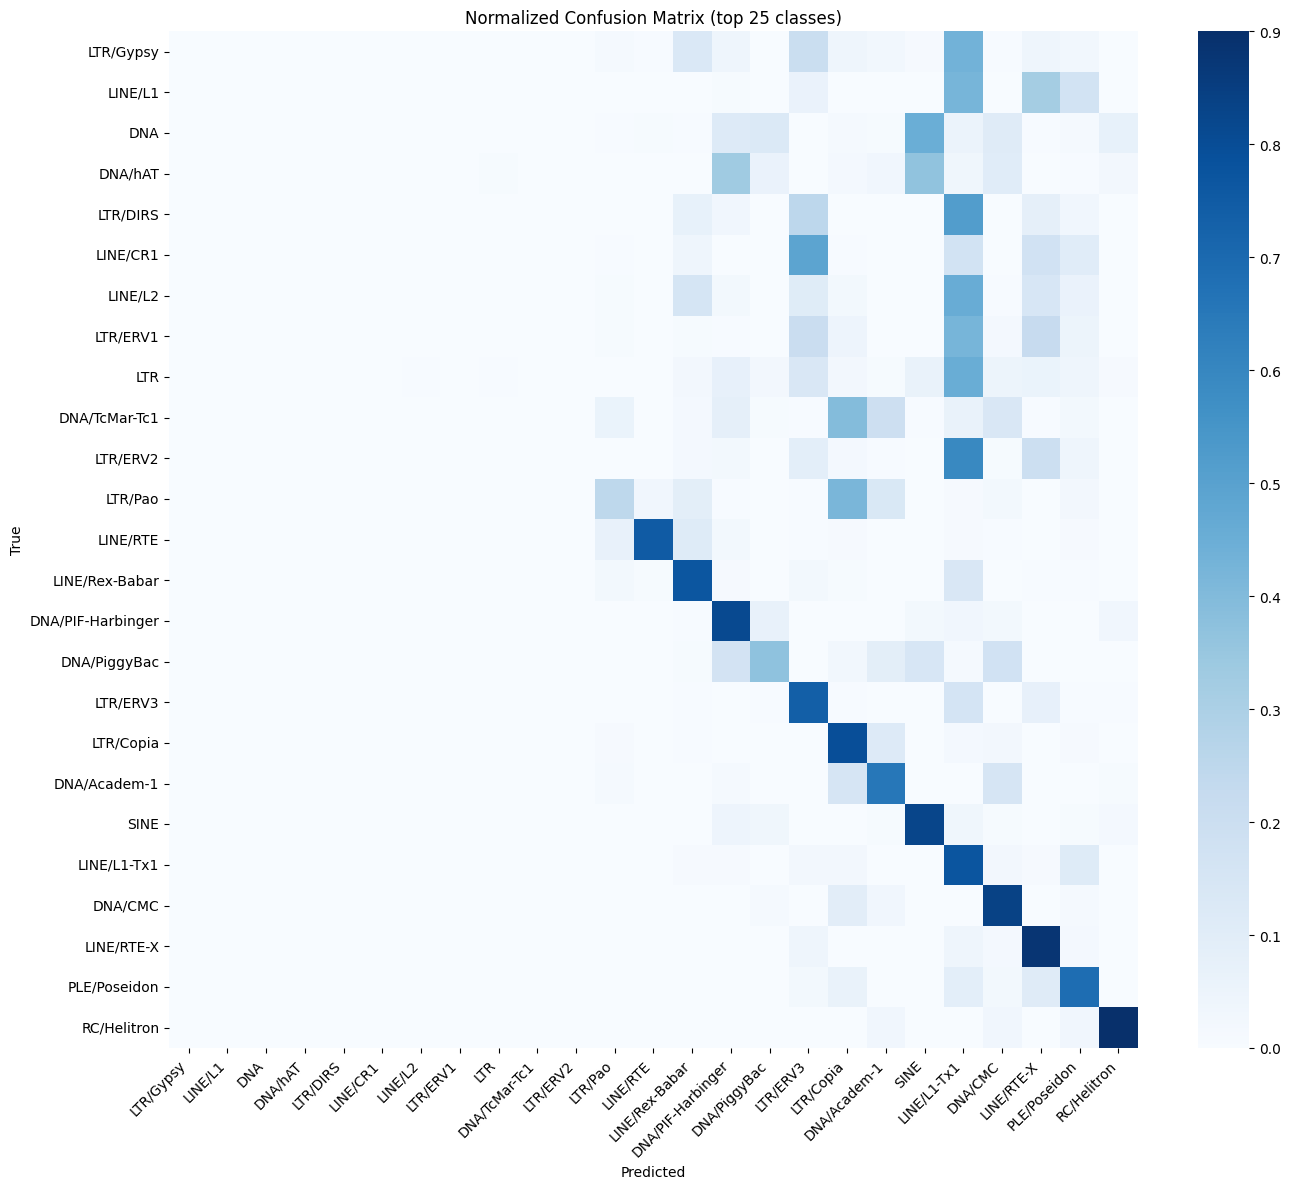

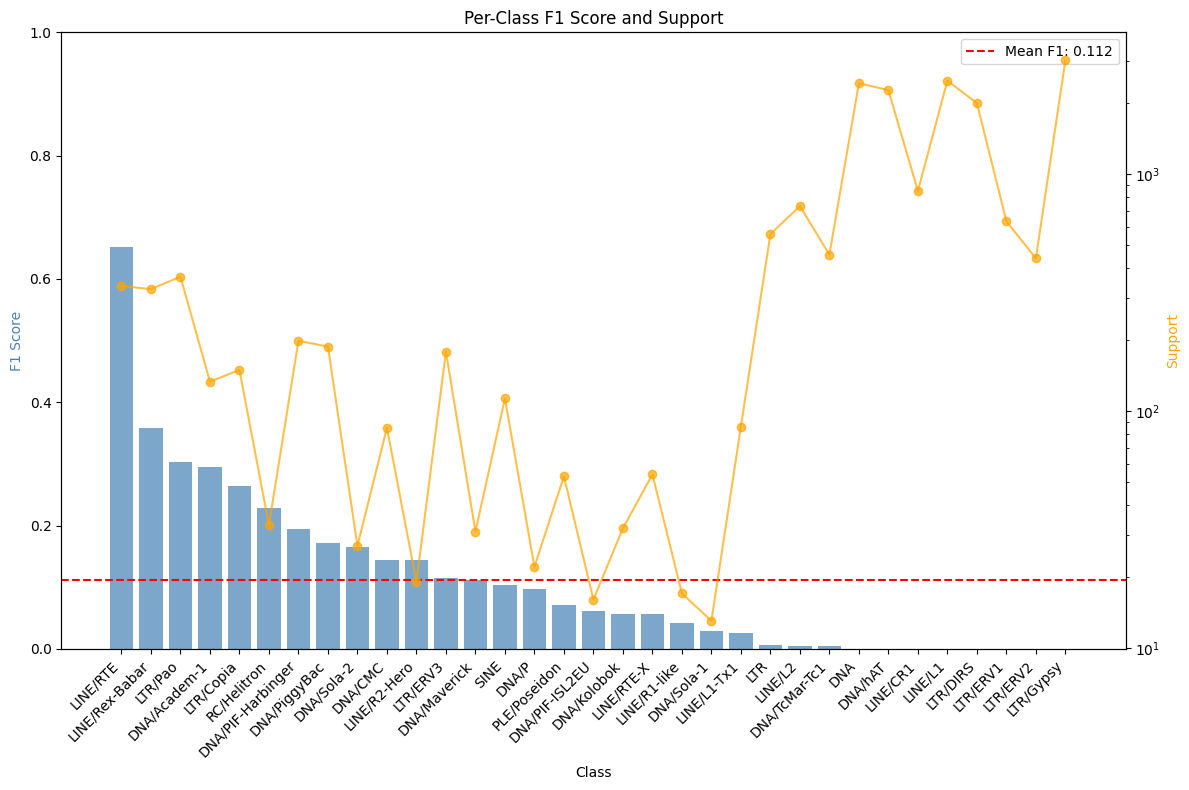


CV Summary:
  acc: 0.0789 ± 0.0114
  balanced_acc: 0.3935 ± 0.0113
  auroc_macro_ovr: 0.8964 ± 0.0070
  auprc_macro: 0.3032 ± 0.0250

Test Results:
  acc: 0.0794
  balanced_acc: 0.4097
  auroc_macro_ovr: 0.9049
  auprc_macro: 0.3341


In [37]:
# ============================================================================
# VISUALIZATION
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm: np.ndarray, labels: List[str], figsize=(14, 12), top_n: int = 20):
    """Plot normalized confusion matrix."""
    # Take top N classes by support for readability
    row_sums = cm.sum(axis=1)
    if len(labels) > top_n:
        top_idx = np.argsort(-row_sums)[:top_n]
        cm_sub = cm[np.ix_(top_idx, top_idx)]
        labels_sub = [labels[i] for i in top_idx]
    else:
        cm_sub = cm
        labels_sub = labels
    
    # Normalize by row
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm_sub.astype(float) / cm_sub.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues', 
                xticklabels=labels_sub, yticklabels=labels_sub, ax=ax)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix (top {len(labels_sub)} classes)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    return fig

def plot_per_class_f1(report: Dict, figsize=(12, 8)):
    """Plot per-class F1 scores."""
    rows = [(k, v['f1-score'], v['support']) 
            for k, v in report.items() 
            if isinstance(v, dict) and 'f1-score' in v and k not in ['accuracy', 'macro avg', 'weighted avg']]
    rows.sort(key=lambda x: -x[1])
    
    labels = [r[0] for r in rows]
    f1s = [r[1] for r in rows]
    supports = [r[2] for r in rows]
    
    fig, ax1 = plt.subplots(figsize=figsize)
    
    x = np.arange(len(labels))
    bars = ax1.bar(x, f1s, color='steelblue', alpha=0.7)
    ax1.set_ylabel('F1 Score', color='steelblue')
    ax1.set_xlabel('Class')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylim(0, 1)
    ax1.axhline(y=np.mean(f1s), color='red', linestyle='--', label=f'Mean F1: {np.mean(f1s):.3f}')
    
    ax2 = ax1.twinx()
    ax2.plot(x, supports, 'o-', color='orange', alpha=0.7, label='Support')
    ax2.set_ylabel('Support', color='orange')
    ax2.set_yscale('log')
    
    ax1.legend(loc='upper right')
    plt.title('Per-Class F1 Score and Support')
    plt.tight_layout()
    return fig

# Plot results if available
if 'results' in dir() and results is not None:
    cm = results['test']['per_class']['confusion_matrix']
    id_to_tag = results['id_to_tag']
    
    fig1 = plot_confusion_matrix(cm, id_to_tag, top_n=25)
    plt.show()
    
    fig2 = plot_per_class_f1(results['test']['per_class']['report'])
    plt.show()
    
    print("\nCV Summary:")
    for k, v in results['cv_metrics'].items():
        print(f"  {k}: {v['mean']:.4f} ± {v['std']:.4f}")
    
    print(f"\nTest Results:")
    for k, v in results['test']['metrics'].items():
        print(f"  {k}: {v:.4f}")

In [39]:
# ============================================================================
# ANALYZE: Why are large classes (DNA, LTR/Gypsy, etc.) performing poorly?
# ============================================================================

def analyze_class_performance(results: Dict, id_to_tag: List[str]):
    """Detailed analysis of per-class performance issues."""
    report = results['test']['per_class']['report']
    cm = results['test']['per_class']['confusion_matrix']
    
    print("="*70)
    print("PER-CLASS ANALYSIS")
    print("="*70)
    
    # Get all classes sorted by support
    rows = []
    for i, tag in enumerate(id_to_tag):
        if tag in report:
            r = report[tag]
            rows.append({
                'idx': i, 'tag': tag, 
                'prec': r['precision'], 'recall': r['recall'], 
                'f1': r['f1-score'], 'support': int(r['support'])
            })
    
    rows.sort(key=lambda x: -x['support'])
    
    print(f"\n{'Class':<20} {'Support':>8} {'Prec':>7} {'Recall':>7} {'F1':>7} | Issue")
    print("-" * 75)
    
    for r in rows[:20]:  # Top 20 by support
        issue = ""
        if r['recall'] < 0.05:
            issue = "❌ Model almost never predicts this class"
        elif r['prec'] < 0.05:
            issue = "⚠️ High FP: Many other classes predicted as this"
        elif r['f1'] < 0.1:
            issue = "⚠️ Low F1"
        elif r['f1'] > 0.3:
            issue = "✓ OK"
        
        print(f"{r['tag']:<20} {r['support']:>8} {r['prec']:>7.3f} {r['recall']:>7.3f} {r['f1']:>7.3f} | {issue}")
    
    # Analyze WHERE the predictions are going for poorly predicted classes
    print("\n" + "="*70)
    print("CONFUSION ANALYSIS: Where are the predictions going?")
    print("="*70)
    
    for r in rows[:10]:  # Top 10 by support
        if r['recall'] < 0.1:  # Poorly recalled classes
            true_idx = r['idx']
            row = cm[true_idx]
            total = row.sum()
            
            # Find top predicted classes for this true class
            top_pred = np.argsort(-row)[:5]
            
            print(f"\nTrue class: {r['tag']} (n={total})")
            print(f"  → Where do predictions go?")
            for pred_idx in top_pred:
                if row[pred_idx] > 0:
                    pct = 100 * row[pred_idx] / total
                    print(f"      → Predicted as {id_to_tag[pred_idx]:<20}: {row[pred_idx]:>5} ({pct:>5.1f}%)")
    
    # Check if "catch-all" classes exist
    print("\n" + "="*70)
    print("'CATCH-ALL' CLASSES: Which classes receive the most false positives?")
    print("="*70)
    
    fp_counts = []
    for i, tag in enumerate(id_to_tag):
        col = cm[:, i]  # All predictions for this class
        tp = cm[i, i]
        fp = col.sum() - tp
        fp_counts.append((tag, fp, tp, col.sum()))
    
    fp_counts.sort(key=lambda x: -x[1])
    
    print(f"\n{'Class':<20} {'FP':>8} {'TP':>8} {'Total Pred':>12} {'FP Rate':>10}")
    print("-" * 65)
    for tag, fp, tp, total in fp_counts[:10]:
        fp_rate = fp / total if total > 0 else 0
        print(f"{tag:<20} {fp:>8} {tp:>8} {total:>12} {fp_rate:>10.1%}")

# Run analysis
if 'results' in dir() and results is not None:
    analyze_class_performance(results, id_to_tag)

PER-CLASS ANALYSIS

Class                 Support    Prec  Recall      F1 | Issue
---------------------------------------------------------------------------
LTR/Gypsy                3021   0.000   0.000   0.000 | ❌ Model almost never predicts this class
LINE/L1                  2480   0.000   0.000   0.000 | ❌ Model almost never predicts this class
DNA                      2419   0.000   0.000   0.000 | ❌ Model almost never predicts this class
DNA/hAT                  2262   0.000   0.000   0.000 | ❌ Model almost never predicts this class
LTR/DIRS                 1994   0.000   0.000   0.000 | ❌ Model almost never predicts this class
LINE/CR1                  849   0.000   0.000   0.000 | ❌ Model almost never predicts this class
LINE/L2                   733   0.077   0.003   0.005 | ❌ Model almost never predicts this class
LTR/ERV1                  632   0.000   0.000   0.000 | ❌ Model almost never predicts this class
LTR                       558   0.087   0.004   0.007 | ❌ Model al

## Analysis: Why Large Classes Have Zero F1

### The Problem
The model is **collapsing predictions onto a few "catch-all" classes**:

| Catch-All Class | False Positives | FP Rate |
|-----------------|-----------------|---------|
| LINE/L1-Tx1 | 4,645 | 98.7% |
| LTR/ERV3 | 1,939 | 93.8% |
| LINE/RTE-X | 1,486 | 97.1% |
| SINE | 1,461 | 94.4% |

### What's Happening
1. **Large classes (LTR/Gypsy, DNA, DNA/hAT, LINE/L1)** are being predicted as smaller, more specific classes
2. The model learns that smaller classes have **distinctive features**, while large classes are **heterogeneous "umbrella" categories**
3. For example, "DNA" contains many different DNA transposon subfamilies - it's essentially a catch-all label

### Semantic Label Hierarchy Issue
Looking at the confusion:
- `LTR/Gypsy` → predicted as `LINE/L1-Tx1` (42%) - This is a **hierarchical label problem**
- `DNA` → predicted as `SINE`, `DNA/Kolobok`, `DNA/PiggyBac` - These ARE DNA transposons!
- `DNA/hAT` → predicted as `SINE`, `DNA/PIF-Harbinger` - Model confuses DNA transposon families

### Root Causes
1. **Only 5 epochs**: Model hasn't converged yet
2. **Class imbalance + Focal Loss**: May be overcorrecting, favoring rare classes
3. **Semantic overlap**: "DNA" is parent of "DNA/hAT", "DNA/PiggyBac", etc.
4. **Label inconsistency**: Some sequences labeled as "DNA" should be "DNA/hAT" etc.

### Solutions to Try
1. **More epochs** (20-30) on GPU
2. **Hierarchical classification**: Predict superfamily → family → subfamily
3. **Merge parent/child labels**: Combine "DNA" with its children, or exclude the generic parent class
4. **Increase model capacity**: hidden=256, layers=4

In [38]:
# ============================================================================
# GENERATE STANDALONE TRAINING SCRIPT FOR GPU CLUSTER
# ============================================================================
# This exports the notebook as a standalone Python script with production settings

SCRIPT_TEMPLATE = '''#!/usr/bin/env python3
"""
GNN TE Classification - GPU Cluster Training Script
Generated from notebook. Run with: python train_gnn_cluster.py
"""
import os
import sys
import argparse
from pathlib import Path
from collections import Counter, namedtuple
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                             roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)
from tqdm import tqdm
import time

# ============================================================================
# DATA LOADING
# ============================================================================
def read_fasta(path: Path) -> Tuple[List[str], List[str]]:
    headers, seqs = [], []
    with open(path) as f:
        seq_parts = []
        header = None
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    seqs.append("".join(seq_parts))
                header = line[1:]
                headers.append(header)
                seq_parts = []
            else:
                seq_parts.append(line)
        if header is not None:
            seqs.append("".join(seq_parts))
    return headers, seqs

def header_to_tag(header: str) -> str:
    parts = header.split("#")
    return parts[1].strip() if len(parts) > 1 else "Unknown"

# ============================================================================
# FEATURE EXTRACTION
# ============================================================================
class KmerWindowFeaturizer:
    def __init__(self, k: int = 7, dim: int = 2048, window: int = 512, stride: int = 256,
                 add_pos: bool = True, l2_normalize: bool = True):
        self.k = k
        self.dim = dim
        self.window = window
        self.stride = stride
        self.add_pos = add_pos
        self.l2_normalize = l2_normalize
        self.base_map = {"A": 0, "C": 1, "G": 2, "T": 3}

    def _kmer_to_hash(self, kmer: str) -> int:
        h = 0
        for c in kmer.upper():
            h = h * 4 + self.base_map.get(c, 0)
        return h % self.dim

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, int]:
        seq = seq.upper()
        L = len(seq)
        if L < self.k:
            starts = [0]
        else:
            starts = list(range(0, max(1, L - self.window + 1), self.stride))
            if starts and starts[-1] + self.window < L:
                starts.append(L - self.window)
        
        n_windows = len(starts)
        out_dim = self.dim + 1 if self.add_pos else self.dim
        X = np.zeros((n_windows, out_dim), dtype=np.float32)
        
        for i, s in enumerate(starts):
            e = min(s + self.window, L)
            substr = seq[s:e]
            if len(substr) >= self.k:
                for j in range(len(substr) - self.k + 1):
                    kmer = substr[j:j + self.k]
                    if all(c in "ACGT" for c in kmer):
                        X[i, self._kmer_to_hash(kmer)] += 1
            norm = np.linalg.norm(X[i, :self.dim])
            if norm > 0 and self.l2_normalize:
                X[i, :self.dim] /= norm
            if self.add_pos:
                X[i, self.dim] = (s + e) / (2.0 * max(1, L))
        return X, n_windows

# ============================================================================
# GRAPH UTILITIES
# ============================================================================
GraphSample = namedtuple("GraphSample", ["x", "edge_index", "y", "header"])

def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.LongTensor:
    if n == 0:
        return torch.empty((2, 0), dtype=torch.long)
    src, dst = [], []
    for i in range(n - 1):
        src.append(i)
        dst.append(i + 1)
        if undirected:
            src.append(i + 1)
            dst.append(i)
    if self_loops:
        for i in range(n):
            src.append(i)
            dst.append(i)
    return torch.tensor([src, dst], dtype=torch.long)

class PrecomputedGraphDataset(torch.utils.data.Dataset):
    def __init__(self, features, labels, headers):
        self.features = features
        self.labels = labels.astype(np.int64)
        self.headers = headers
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        X = self.features[idx]
        x = torch.from_numpy(X).to(torch.float32)
        ei = build_chain_edge_index(x.size(0), undirected=True, self_loops=True)
        y = torch.tensor(int(self.labels[idx]), dtype=torch.int64)
        return GraphSample(x=x, edge_index=ei, y=y, header=self.headers[idx])

def collate_graphs(batch):
    xs, eis, ys, hs = [], [], [], []
    offset = 0
    for g in batch:
        xs.append(g.x)
        eis.append(g.edge_index + offset)
        ys.append(g.y)
        hs.append(g.header)
        offset += g.x.size(0)
    x = torch.cat(xs, dim=0)
    ei = torch.cat(eis, dim=1)
    y = torch.stack(ys, dim=0)
    batch_vec = torch.cat([torch.full((g.x.size(0),), i, dtype=torch.long) for i, g in enumerate(batch)])
    return x, ei, batch_vec, y, hs

# ============================================================================
# GNN MODEL
# ============================================================================
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.lin_neigh = nn.Linear(in_dim, out_dim, bias=False)
        self.lin_self = nn.Linear(in_dim, out_dim, bias=True)
    
    def forward(self, x, edge_index):
        src, dst = edge_index
        neigh = torch.zeros_like(x)
        counts = torch.zeros(x.size(0), 1, device=x.device)
        neigh.scatter_add_(0, dst.unsqueeze(1).expand(-1, x.size(1)), x[src])
        counts.scatter_add_(0, dst.unsqueeze(1), torch.ones_like(src, dtype=torch.float).unsqueeze(1))
        counts = counts.clamp(min=1)
        neigh = neigh / counts
        return self.lin_self(x) + self.lin_neigh(neigh)

class GNNClassifier(nn.Module):
    def __init__(self, in_dim, hidden, num_classes, n_layers=3, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        dims = [in_dim] + [hidden] * n_layers
        for i in range(n_layers):
            self.layers.append(GraphSAGELayer(dims[i], dims[i + 1]))
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, num_classes)
    
    def forward(self, x, edge_index, batch):
        for layer in self.layers:
            x = F.relu(layer(x, edge_index))
            x = self.drop(x)
        pooled = torch.zeros(batch.max() + 1, x.size(1), device=x.device)
        pooled.scatter_add_(0, batch.unsqueeze(1).expand(-1, x.size(1)), x)
        counts = torch.bincount(batch, minlength=batch.max() + 1).float().unsqueeze(1)
        pooled = pooled / counts.clamp(min=1)
        return self.head(pooled)

# ============================================================================
# TRAINING UTILITIES
# ============================================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
    
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, 
                             reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def compute_class_weights(y, num_classes):
    counts = np.bincount(y, minlength=num_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    w = counts.sum() / counts
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    logits_list, y_list = [], []
    for x, ei, bv, y, _ in loader:
        logits = model(x.to(device), ei.to(device), bv.to(device))
        logits_list.append(logits.cpu())
        y_list.append(y.cpu())
    return torch.cat(logits_list), torch.cat(y_list)

def evaluate_multiclass(logits, y):
    y_np = y.numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    out = {'acc': accuracy_score(y_np, pred), 'balanced_acc': balanced_accuracy_score(y_np, pred)}
    try:
        out['auroc'] = roc_auc_score(y_np, probs, multi_class='ovr', average='macro')
    except:
        out['auroc'] = float('nan')
    return out

# ============================================================================
# MAIN TRAINING
# ============================================================================
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--fasta', type=str, required=True)
    parser.add_argument('--out', type=str, default='./output')
    parser.add_argument('--epochs', type=int, default=30)
    parser.add_argument('--batch', type=int, default=64)
    parser.add_argument('--hidden', type=int, default=256)
    parser.add_argument('--layers', type=int, default=4)
    parser.add_argument('--lr', type=float, default=1e-3)
    parser.add_argument('--folds', type=int, default=5)
    parser.add_argument('--min-class', type=int, default=50)
    parser.add_argument('--workers', type=int, default=4)
    args = parser.parse_args()
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    
    # Load data
    headers, sequences = read_fasta(Path(args.fasta))
    tags = [header_to_tag(h) for h in headers]
    
    # Filter
    exclude = {'Unknown'}
    keep = [(h, s, t) for h, s, t in zip(headers, sequences, tags) if t not in exclude]
    headers, sequences, tags = zip(*keep)
    headers, sequences, tags = list(headers), list(sequences), list(tags)
    
    # Label encoding
    from collections import Counter
    tag_counts = Counter(tags)
    tag_to_id = {t: i for i, t in enumerate(sorted(set(tags)))}
    id_to_tag = list(tag_to_id.keys())
    y = np.array([tag_to_id[t] for t in tags])
    
    # Drop rare
    counts = np.bincount(y)
    keep_cls = np.where(counts >= args.min_class)[0]
    keep_mask = np.isin(y, keep_cls)
    headers = [h for h, m in zip(headers, keep_mask) if m]
    sequences = [s for s, m in zip(sequences, keep_mask) if m]
    y = y[keep_mask]
    old_to_new = {old: new for new, old in enumerate(keep_cls)}
    y = np.array([old_to_new[i] for i in y])
    id_to_tag = [id_to_tag[old] for old in keep_cls]
    
    print(f"Final: {len(sequences)} sequences, {len(id_to_tag)} classes")
    
    # Featurize
    feat = KmerWindowFeaturizer(k=7, dim=2048, window=512, stride=256)
    print("Featurizing...")
    features = [feat.featurize_sequence(s)[0] for s in tqdm(sequences)]
    
    # Train
    idx = np.arange(len(sequences))
    idx_train, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
    
    skf = StratifiedKFold(n_splits=args.folds, shuffle=True, random_state=42)
    in_dim = 2048 + 1
    
    for fold_i, (tr, va) in enumerate(skf.split(idx_train, y[idx_train])):
        print(f"\\nFold {fold_i + 1}/{args.folds}")
        
        ds_tr = PrecomputedGraphDataset([features[idx_train[i]] for i in tr], y[idx_train[tr]], 
                                        [headers[idx_train[i]] for i in tr])
        ds_va = PrecomputedGraphDataset([features[idx_train[i]] for i in va], y[idx_train[va]],
                                        [headers[idx_train[i]] for i in va])
        
        loader_tr = torch.utils.data.DataLoader(ds_tr, batch_size=args.batch, shuffle=True,
                                                  num_workers=args.workers, collate_fn=collate_graphs)
        loader_va = torch.utils.data.DataLoader(ds_va, batch_size=args.batch, shuffle=False,
                                                  num_workers=args.workers, collate_fn=collate_graphs)
        
        model = GNNClassifier(in_dim, args.hidden, len(id_to_tag), args.layers, 0.2).to(device)
        class_w = compute_class_weights(y[idx_train[tr]], len(id_to_tag)).to(device)
        loss_fn = FocalLoss(alpha=class_w, gamma=2.0)
        opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=args.epochs)
        
        scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
        
        best_score, best_state = -1, None
        for ep in range(1, args.epochs + 1):
            model.train()
            for x, ei, bv, yb, _ in loader_tr:
                x, ei, bv, yb = x.to(device), ei.to(device), bv.to(device), yb.to(device)
                if scaler:
                    with torch.amp.autocast('cuda'):
                        loss = loss_fn(model(x, ei, bv), yb)
                    opt.zero_grad(set_to_none=True)
                    scaler.scale(loss).backward()
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(opt)
                    scaler.update()
                else:
                    loss = loss_fn(model(x, ei, bv), yb)
                    opt.zero_grad(set_to_none=True)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
            scheduler.step()
            
            val_logits, val_y = predict_loader(model, loader_va, device)
            m = evaluate_multiclass(val_logits, val_y)
            print(f"  Ep {ep:02d} | bacc={m['balanced_acc']:.4f} | auroc={m['auroc']:.4f}")
            
            if m['balanced_acc'] > best_score:
                best_score = m['balanced_acc']
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        # Save fold
        out_dir = Path(args.out)
        out_dir.mkdir(parents=True, exist_ok=True)
        torch.save({'state': best_state, 'id_to_tag': id_to_tag, 'best_bacc': best_score}, 
                   out_dir / f'fold_{fold_i}.pt')
    
    print("\\nDone!")

if __name__ == '__main__':
    main()
'''

# Write script to file
script_path = Path("../models/train_gnn_cluster.py")
script_path.parent.mkdir(parents=True, exist_ok=True)
with open(script_path, "w") as f:
    f.write(SCRIPT_TEMPLATE)

print(f"✅ Saved cluster training script to: {script_path}")
print(f"""
To run on GPU cluster:
  python train_gnn_cluster.py --fasta /path/to/all_vgp_tes.fa --out ./output --epochs 30 --batch 64 --hidden 256 --layers 4

Options:
  --fasta      Path to FASTA file
  --out        Output directory for checkpoints
  --epochs     Number of epochs (default: 30)
  --batch      Batch size (default: 64, increase for GPU)
  --hidden     Hidden dimension (default: 256)
  --layers     Number of GNN layers (default: 4)
  --lr         Learning rate (default: 0.001)
  --folds      K-fold CV folds (default: 5)
  --min-class  Minimum samples per class (default: 50)
  --workers    DataLoader workers (default: 4)
""")

✅ Saved cluster training script to: ../models/train_gnn_cluster.py

To run on GPU cluster:
  python train_gnn_cluster.py --fasta /path/to/all_vgp_tes.fa --out ./output --epochs 30 --batch 64 --hidden 256 --layers 4

Options:
  --fasta      Path to FASTA file
  --out        Output directory for checkpoints
  --epochs     Number of epochs (default: 30)
  --batch      Batch size (default: 64, increase for GPU)
  --hidden     Hidden dimension (default: 256)
  --layers     Number of GNN layers (default: 4)
  --lr         Learning rate (default: 0.001)
  --folds      K-fold CV folds (default: 5)
  --min-class  Minimum samples per class (default: 50)
  --workers    DataLoader workers (default: 4)



In [33]:
# --- Alternative: Use FASTA header labels (all TE classes) ---
# This uses the full ~135k sequences with labels from FASTA headers
# The 8% transposase classes will be mixed with LTR, LINE, etc.

def run_train_gnn_fasta_labels(
    fasta_path: Path,
    exclude_tags: Optional[List[str]] = None,
    min_class_count: int = 50,
    **kwargs
):
    """Train using FASTA header labels instead of features-tpase file."""
    headers, sequences = read_fasta(Path(fasta_path))
    print(f"Loaded {len(sequences)} sequences")
    
    # Extract labels from FASTA headers
    tags = [header_to_tag(h) for h in headers]
    
    # Show distribution
    from collections import Counter
    tag_counts = Counter(tags)
    print(f"\nAll classes ({len(tag_counts)}):")
    for tag, cnt in tag_counts.most_common(20):
        print(f"  {tag}: {cnt}")
    if len(tag_counts) > 20:
        print(f"  ... and {len(tag_counts) - 20} more classes")
    
    # Count how many would remain after filtering
    kept = sum(1 for t, c in tag_counts.items() if c >= min_class_count and t not in (exclude_tags or []))
    print(f"\nWith min_class_count={min_class_count}, exclude={exclude_tags}:")
    print(f"  Would keep {kept} classes")
    
    return tag_counts

# Quick analysis: What happens if we use all FASTA data?
print("="*60)
print("ANALYSIS: Using FASTA header labels (all TE classes)")
print("="*60)
tag_counts = run_train_gnn_fasta_labels(
    fasta_path=Path("../data/vgp/all_vgp_tes.fa"),
    exclude_tags=["Unknown"],
    min_class_count=50,
)

ANALYSIS: Using FASTA header labels (all TE classes)
Loaded 135751 sequences

All classes (48):
  Unknown: 43919
  LTR/Gypsy: 15103
  LINE/L1: 12401
  DNA: 12094
  DNA/hAT: 11308
  LTR/DIRS: 9970
  LINE/CR1: 4242
  LINE/L2: 3666
  LTR/ERV1: 3161
  LTR: 2789
  DNA/TcMar-Tc1: 2283
  LTR/ERV2: 2202
  LTR/Pao: 1842
  LINE/RTE: 1683
  LINE/Rex-Babar: 1634
  DNA/PIF-Harbinger: 992
  DNA/PiggyBac: 937
  LTR/ERV3: 888
  LTR/Copia: 745
  DNA/Academ-1: 663
  ... and 28 more classes

With min_class_count=50, exclude=['Unknown']:
  Would keep 33 classes
